## Seccion 0 - Setup e instalacion

- Imports.
- Definicion de semilla reproducible.
- Definicion de `DEVICE`.
- Rutas del proyecto y outputs.


In [34]:
# Dependencias usadas en este notebook:
# medmnist, numpy, pandas, matplotlib, seaborn, scikit-learn, torch, torchvision, tqdm
# Si falta alguna en un entorno nuevo, instalar desde una celda separada, por ejemplo:
# %pip install medmnist numpy pandas matplotlib seaborn scikit-learn torch torchvision tqdm


In [35]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights
import medmnist
from medmnist import INFO, PathMNIST

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tqdm.auto import tqdm

In [36]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA_FLAG = "pathmnist"
SIZE = 28
BATCH_SIZE = 256
NUM_WORKERS = 2

info = INFO[DATA_FLAG]
DataClass = getattr(medmnist, info["python_class"])

n_classes = len(info["label"])
class_names = [info["label"][str(i)] for i in range(n_classes)]

print("Dispositivo:", DEVICE)
print("Dataset:", DATA_FLAG)
print("Resolución:", SIZE, "x", SIZE)
print("Número de clases:", n_classes)
print("Clases:", class_names)

Dispositivo: cuda
Dataset: pathmnist
Resolución: 28 x 28
Número de clases: 9
Clases: ['adipose', 'background', 'debris', 'lymphocytes', 'mucus', 'smooth muscle', 'normal colon mucosa', 'cancer-associated stroma', 'colorectal adenocarcinoma epithelium']


---

## Seccion 1 - Carga del dataset PathMNIST

- Cargar `train`, `val` y `test`.
- Mostrar tamanos oficiales.
- Usar los splits oficiales de MedMNIST.
- No usar `random_split`.


In [37]:
train_dataset = PathMNIST(split="train", download=True)
val_dataset = PathMNIST(split="val", download=True)
test_dataset = PathMNIST(split="test", download=True)

split_sizes = info["n_samples"]

holdout_df = pd.DataFrame({
    "Conjunto": ["Training", "Validation", "Test"],
    "Split oficial MedMNIST": ["train", "val", "test"],
    "Cantidad de imágenes": [
        split_sizes["train"],
        split_sizes["val"],
        split_sizes["test"]
    ],
    "Uso experimental": [
        "Entrenar los pesos del modelo",
        "Elegir el mejor modelo durante el entrenamiento",
        "Evaluar el rendimiento final una sola vez"
    ]
})

display(holdout_df)


,Conjunto,Split oficial MedMNIST,Cantidad de imágenes,Uso experimental
0,Training,train,89996,Entrenar los pesos del modelo
1,Validation,val,10004,Elegir el mejor modelo durante el entrenamiento
2,Test,test,7180,Evaluar el rendimiento final una sola vez


In [38]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.7405, 0.5330, 0.7058], std=[0.1237, 0.1768, 0.1244])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.7405, 0.5330, 0.7058],
        std=[0.1237, 0.1768, 0.1244]
    )
])

train_dataset = DataClass(
    split="train",
    transform=train_transform,
    download=True,
    size=SIZE
)
val_dataset = DataClass(
    split="val",
    transform=val_test_transform,
    download=True,
    size=SIZE
)
test_dataset = DataClass(
    split="test",
    transform=val_test_transform,
    download=True,
    size=SIZE
)

---

## Seccion 2 - EDA global del dataset

Esta seccion queda preparada para integrar el EDA. Las variables `raw_train_dataset`, `raw_val_dataset`, `raw_test_dataset`, `class_names` y `class_id_to_name` ya estan disponibles.


In [39]:
DATA_FLAG = "pathmnist"
DATASET_NAME = "PathMNIST"
TARGET_RESOLUTION = "28x28"
EXPECTED_TASK = "multi-class"
EXPECTED_CHANNELS = 3
EXPECTED_NUM_CLASSES = 9
EXPECTED_IMAGE_SHAPE = (28, 28, 3)

info = INFO[DATA_FLAG]
task = info["task"]
n_channels = info["n_channels"]
n_classes = len(info["label"])
class_labels = info["label"]
n_samples = info["n_samples"]

datasets = {
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset,
}

classes_df = pd.DataFrame({
    "class_id": [int(class_id) for class_id in class_labels.keys()],
    "class_name": list(class_labels.values())
}).sort_values("class_id").reset_index(drop=True)
expected_split_sizes = {
    "train": n_samples["train"],
    "validation": n_samples["val"],
    "test": n_samples["test"],
}

split_size_df = pd.DataFrame([
    {
        "split": split_name,
        "num_images_observed": len(dataset),
        "num_images_expected": expected_split_sizes[split_name],
        "matches_expected": len(dataset) == expected_split_sizes[split_name],
        "image_shape": dataset.imgs.shape[1:],
        "label_shape": dataset.labels.shape,
    }
    for split_name, dataset in datasets.items()
])

class_id_to_name = dict(zip(classes_df["class_id"], classes_df["class_name"]))

display(split_size_df)

assert task == EXPECTED_TASK
assert n_channels == EXPECTED_CHANNELS
assert n_classes == EXPECTED_NUM_CLASSES

for split_name, dataset in datasets.items():
    assert len(dataset) == expected_split_sizes[split_name]
    assert dataset.imgs.shape[1:] == EXPECTED_IMAGE_SHAPE
    assert dataset.labels.shape[0] == dataset.imgs.shape[0]

print("Carga y validaciones mínimas completadas correctamente.")

,split,num_images_observed,num_images_expected,matches_expected,image_shape,label_shape
0,train,89996,89996,True,"(28, 28, 3)","(89996, 1)"
1,validation,10004,10004,True,"(28, 28, 3)","(10004, 1)"
2,test,7180,7180,True,"(28, 28, 3)","(7180, 1)"


Carga y validaciones mínimas completadas correctamente.


In [40]:
def inspect_dataset_structure(dataset, split_name):
    images = dataset.imgs
    labels = dataset.labels
    return {
        "split": split_name,
        "num_images": images.shape[0],
        "image_height": images.shape[1],
        "image_width": images.shape[2],
        "num_channels": images.shape[3],
        "image_dtype": str(images.dtype),
        "label_shape": labels.shape,
        "label_dtype": str(labels.dtype),
        "pixel_min": int(images.min()),
        "pixel_max": int(images.max()),
    }

structure_df = pd.DataFrame([
    inspect_dataset_structure(dataset, split_name)
    for split_name, dataset in datasets.items()
])

display(structure_df)


,split,num_images,image_height,image_width,num_channels,image_dtype,label_shape,label_dtype,pixel_min,pixel_max
0,train,89996,28,28,3,uint8,"(89996, 1)",uint8,0,255
1,validation,10004,28,28,3,uint8,"(10004, 1)",uint8,0,255
2,test,7180,28,28,3,uint8,"(7180, 1)",uint8,0,255


In [41]:
def compute_class_distribution(dataset, split_name, class_id_to_name):
    labels = dataset.labels.reshape(-1).astype(int)
    unique_labels, counts = np.unique(labels, return_counts=True)
    total = labels.shape[0]

    rows = []
    for class_id, count in zip(unique_labels, counts):
        rows.append({
            "split": split_name,
            "class_id": int(class_id),
            "class_name": class_id_to_name[int(class_id)],
            "count": int(count),
            "percentage": 100 * count / total,
        })

    return pd.DataFrame(rows)

class_distribution_df = pd.concat([
    compute_class_distribution(dataset, split_name, class_id_to_name)
    for split_name, dataset in datasets.items()
], ignore_index=True)

class_count_pivot = class_distribution_df.pivot(
    index=["class_id", "class_name"],
    columns="split",
    values="count"
).reset_index()

class_percentage_pivot = class_distribution_df.pivot(
    index=["class_id", "class_name"],
    columns="split",
    values="percentage"
).reset_index()

for column in ["train", "validation", "test"]:
    class_percentage_pivot[column] = class_percentage_pivot[column].round(2)

imbalance_df = class_distribution_df.groupby("split").agg(
    min_class_count=("count", "min"),
    max_class_count=("count", "max"),
    mean_class_count=("count", "mean"),
).reset_index()
imbalance_df["max_to_min_ratio"] = (
    imbalance_df["max_class_count"] / imbalance_df["min_class_count"]
).round(3)

split_difference_df = class_percentage_pivot[["class_id", "class_name"]].copy()
split_difference_df["validation_minus_train"] = (
    class_percentage_pivot["validation"] - class_percentage_pivot["train"]
).round(2)
split_difference_df["test_minus_train"] = (
    class_percentage_pivot["test"] - class_percentage_pivot["train"]
).round(2)

print("Conteos por clase y split")
display(class_count_pivot)
print("Porcentajes por clase y split")
display(class_percentage_pivot)
print("Resumen de desbalance")
display(imbalance_df)
print("Diferencias porcentuales respecto a train")
display(split_difference_df)


Conteos por clase y split


split,class_id,class_name,test,train,validation
0,0,adipose,1338,9366,1041
1,1,background,847,9509,1057
2,2,debris,339,10360,1152
3,3,lymphocytes,634,10401,1156
4,4,mucus,1035,8006,890
5,5,smooth muscle,592,12182,1354
6,6,normal colon mucosa,741,7886,877
7,7,cancer-associated stroma,421,9401,1045
8,8,colorectal adenocarcinoma epithelium,1233,12885,1432


Porcentajes por clase y split


split,class_id,class_name,test,train,validation
0,0,adipose,18.64,10.41,10.41
1,1,background,11.80,10.57,10.57
2,2,debris,4.72,11.51,11.52
3,3,lymphocytes,8.83,11.56,11.56
4,4,mucus,14.42,8.90,8.90
5,5,smooth muscle,8.25,13.54,13.53
6,6,normal colon mucosa,10.32,8.76,8.77
7,7,cancer-associated stroma,5.86,10.45,10.45
8,8,colorectal adenocarcinoma epithelium,17.17,14.32,14.31


Resumen de desbalance


,split,min_class_count,max_class_count,mean_class_count,max_to_min_ratio
0,test,339,1338,797.777778,3.947
1,train,7886,12885,9999.555556,1.634
2,validation,877,1432,1111.555556,1.633


Diferencias porcentuales respecto a train


split,class_id,class_name,validation_minus_train,test_minus_train
0,0,adipose,0.00,8.23
1,1,background,0.00,1.23
2,2,debris,0.01,-6.79
3,3,lymphocytes,0.00,-2.73
4,4,mucus,0.00,5.52
5,5,smooth muscle,-0.01,-5.29
6,6,normal colon mucosa,0.01,1.56
7,7,cancer-associated stroma,0.00,-4.59
8,8,colorectal adenocarcinoma epithelium,-0.01,2.85


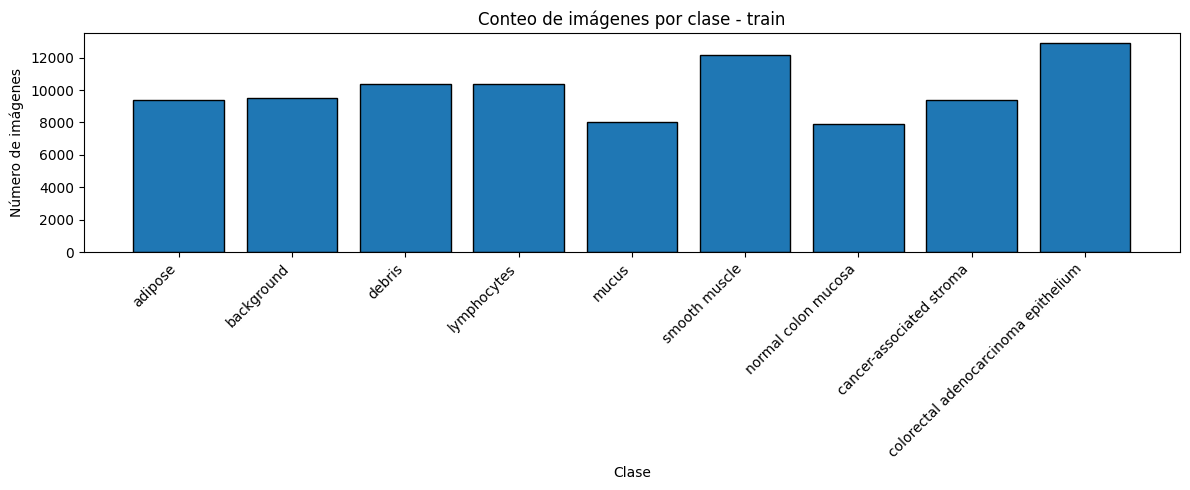

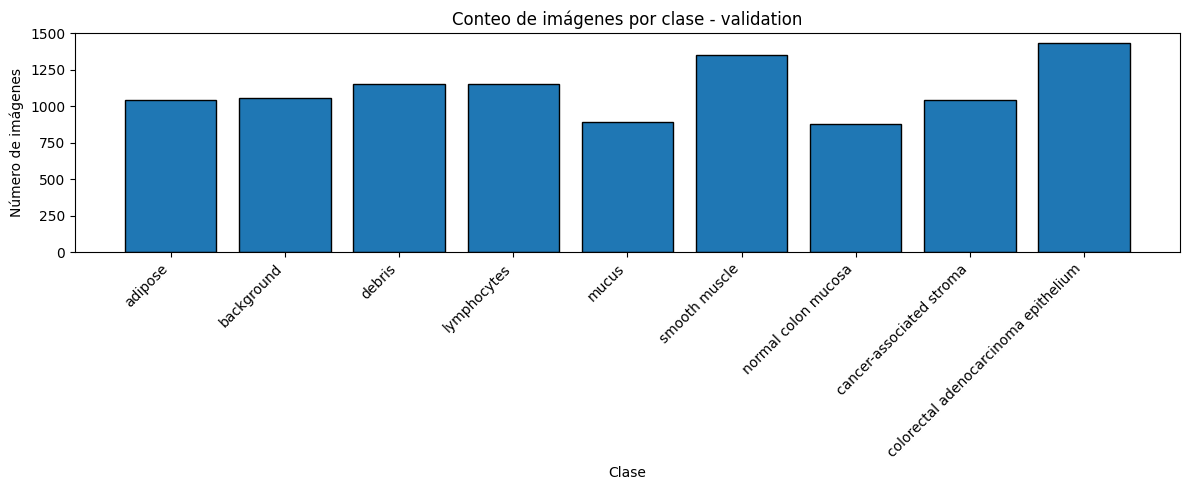

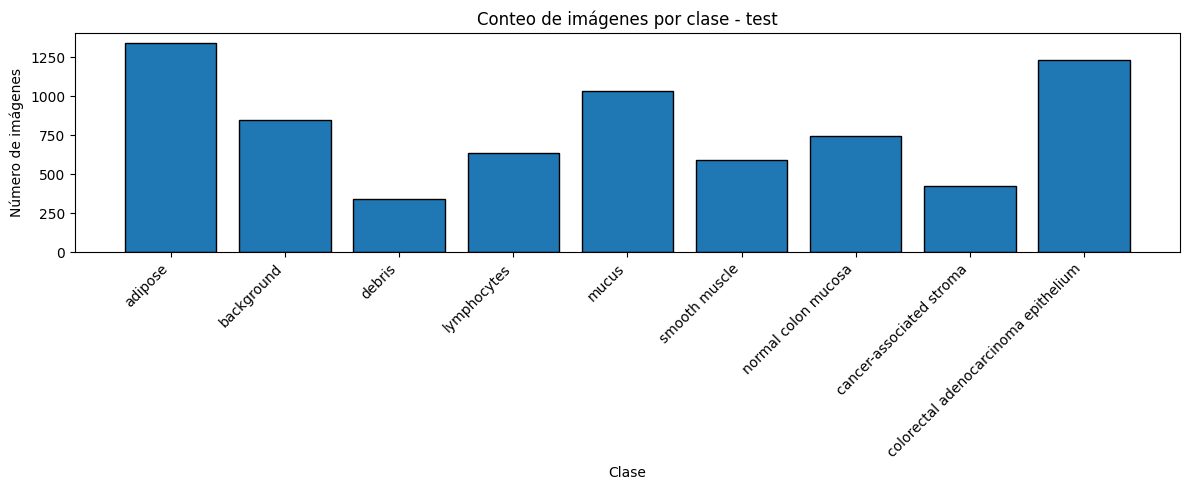

In [42]:
for split_name in ["train", "validation", "test"]:
    split_data = class_distribution_df[class_distribution_df["split"] == split_name]

    plt.figure(figsize=(12, 5))
    plt.bar(split_data["class_name"], split_data["count"], edgecolor="black")
    plt.title(f"Conteo de imágenes por clase - {split_name}")
    plt.xlabel("Clase")
    plt.ylabel("Número de imágenes")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

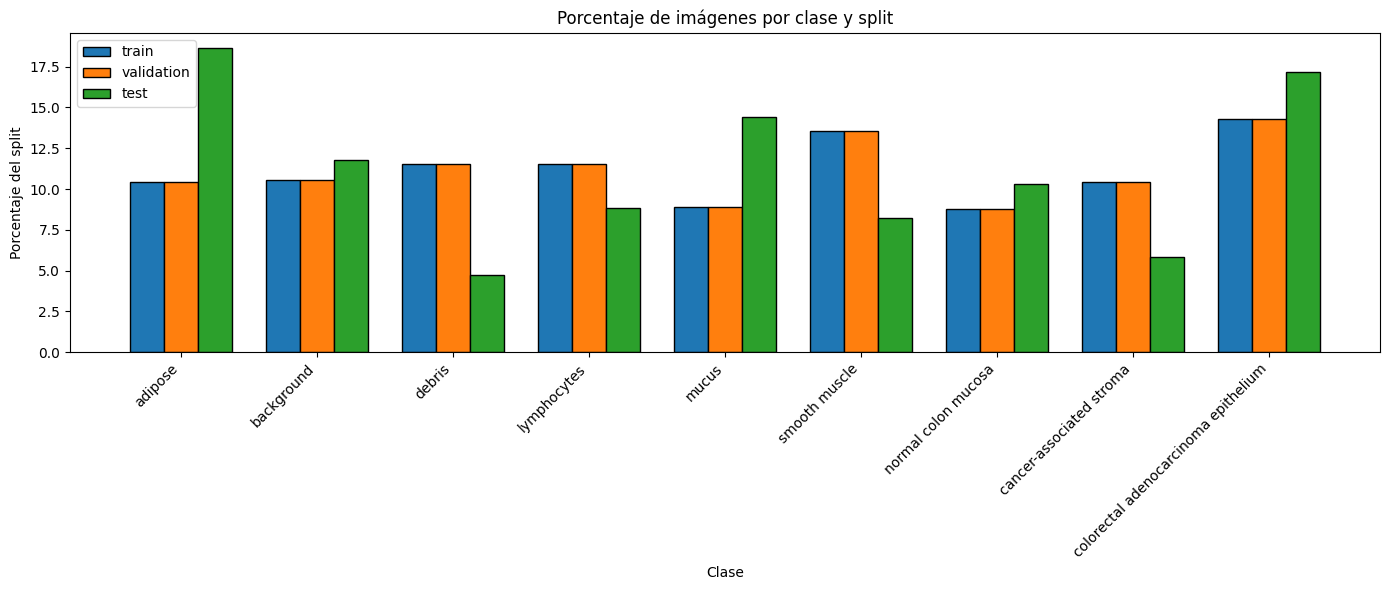

In [43]:
x = np.arange(len(class_percentage_pivot["class_name"]))
width = 0.25

plt.figure(figsize=(14, 6))
plt.bar(x - width, class_percentage_pivot["train"], width, label="train", edgecolor="black")
plt.bar(x, class_percentage_pivot["validation"], width, label="validation", edgecolor="black")
plt.bar(x + width, class_percentage_pivot["test"], width, label="test", edgecolor="black")
plt.title("Porcentaje de imágenes por clase y split")
plt.xlabel("Clase")
plt.ylabel("Porcentaje del split")
plt.xticks(x, class_percentage_pivot["class_name"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

x = np.arange(len(split_difference_df["class_name"]))
width = 0.35



In [44]:
visual_coverage_df = class_distribution_df.pivot(
    index=["class_id", "class_name"],
    columns="split",
    values="count"
).reset_index()

visual_coverage_df["min_available_across_splits"] = visual_coverage_df[
    ["train", "validation", "test"]
].min(axis=1)

display(visual_coverage_df)

split,class_id,class_name,test,train,validation,min_available_across_splits
0,0,adipose,1338,9366,1041,1041
1,1,background,847,9509,1057,847
2,2,debris,339,10360,1152,339
3,3,lymphocytes,634,10401,1156,634
4,4,mucus,1035,8006,890,890
5,5,smooth muscle,592,12182,1354,592
6,6,normal colon mucosa,741,7886,877,741
7,7,cancer-associated stroma,421,9401,1045,421
8,8,colorectal adenocarcinoma epithelium,1233,12885,1432,1233


In [45]:
def sample_indices_by_class(dataset, class_id, n_samples=3, seed=42):
    labels = dataset.labels.reshape(-1).astype(int)
    candidate_indices = np.where(labels == class_id)[0]
    rng = np.random.default_rng(seed)
    selected = rng.choice(
        candidate_indices,
        size=min(n_samples, len(candidate_indices)),
        replace=False,
    )
    return selected


def plot_all_classes_across_splits(datasets, class_id_to_name, seed=42):
    class_ids = sorted(class_id_to_name.keys())
    split_names = ["train", "validation", "test"]

    fig, axes = plt.subplots(
        nrows=len(class_ids),
        ncols=len(split_names),
        figsize=(9, 2.1 * len(class_ids)),
    )

    for row_idx, class_id in enumerate(class_ids):
        for col_idx, split_name in enumerate(split_names):
            dataset = datasets[split_name]
            selected_idx = sample_indices_by_class(dataset, class_id, n_samples=1, seed=seed + row_idx + col_idx)[0]
            image = dataset.imgs[selected_idx]

            ax = axes[row_idx, col_idx]
            ax.imshow(image)
            ax.axis("off")
            if row_idx == 0:
                ax.set_title(split_name)
            if col_idx == 0:
                ax.set_ylabel(f"{class_id}: {class_id_to_name[class_id]}", rotation=0, ha="right", va="center")

    fig.suptitle("Muestra visual por clase y split", y=1.01, fontsize=14)
    plt.tight_layout()
    plt.show()




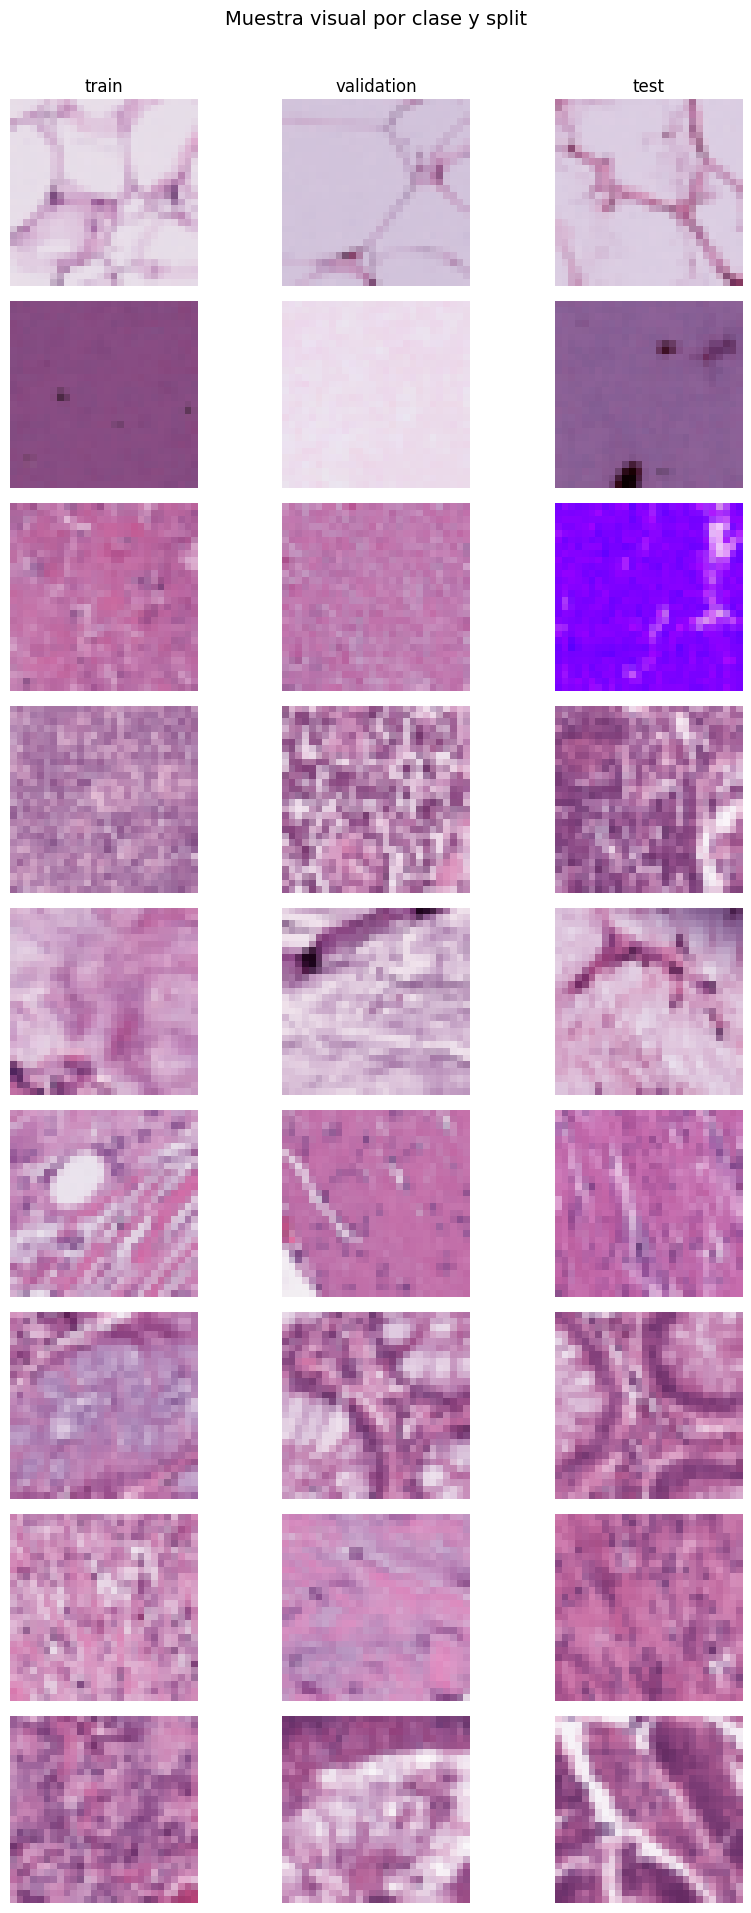

In [46]:
plot_all_classes_across_splits(datasets, class_id_to_name, seed=SEED)


In [47]:
def compute_global_rgb_statistics(dataset, split_name):
    images = dataset.imgs.astype(np.float32)
    channel_names = ["R", "G", "B"]
    rows = []

    for channel_idx, channel_name in enumerate(channel_names):
        values = images[:, :, :, channel_idx].reshape(-1)
        rows.append({
            "split": split_name,
            "channel": channel_name,
            "min": values.min(),
            "p01": np.percentile(values, 1),
            "mean": values.mean(),
            "median": np.median(values),
            "p99": np.percentile(values, 99),
            "max": values.max(),
            "std": values.std(),
        })

    return pd.DataFrame(rows)

global_rgb_stats_df = pd.concat([
    compute_global_rgb_statistics(dataset, split_name)
    for split_name, dataset in datasets.items()
], ignore_index=True)

rgb_mean_pivot = global_rgb_stats_df.pivot(index="split", columns="channel", values="mean").reset_index()
rgb_std_pivot = global_rgb_stats_df.pivot(index="split", columns="channel", values="std").reset_index()

rgb_mean_display = rgb_mean_pivot.copy()
rgb_std_display = rgb_std_pivot.copy()
for df in [rgb_mean_display, rgb_std_display]:
    for channel in ["R", "G", "B"]:
        df[channel] = df[channel].round(2)

train_rgb_mean_255 = rgb_mean_pivot[rgb_mean_pivot["split"] == "train"][["R", "G", "B"]].iloc[0].to_numpy()
train_rgb_std_255 = rgb_std_pivot[rgb_std_pivot["split"] == "train"][["R", "G", "B"]].iloc[0].to_numpy()

normalization_stats_df = pd.DataFrame({
    "channel": ["R", "G", "B"],
    "mean_0_255": train_rgb_mean_255,
    "std_0_255": train_rgb_std_255,
    "mean_0_1": train_rgb_mean_255 / 255.0,
    "std_0_1": train_rgb_std_255 / 255.0,
}).round(4)

print("Medias RGB por split")
display(rgb_mean_display)
print("Desviaciones estándar RGB por split")
display(rgb_std_display)
print("Parámetros recomendados de normalización basados solo en train")
display(normalization_stats_df)


Medias RGB por split


channel,split,B,G,R
0,test,180.850006,136.520004,185.350006
1,train,179.990005,135.910004,188.839996
2,validation,180.270004,136.300003,189.080002


Desviaciones estándar RGB por split


channel,split,B,G,R
0,test,38.549999,53.48,37.520000
1,train,31.730000,45.07,31.540001
2,validation,31.709999,45.18,31.400000


Parámetros recomendados de normalización basados solo en train


,channel,mean_0_255,std_0_255,mean_0_1,std_0_1
0,R,188.839005,31.539000,0.7405,0.1237
1,G,135.910507,45.074402,0.5330,0.1768
2,B,179.986404,31.729799,0.7058,0.1244


In [48]:
def compute_image_quality_metrics(dataset, split_name, class_id_to_name):
    images = dataset.imgs.astype(np.float32)
    labels = dataset.labels.reshape(-1).astype(int)
    rows = []

    for idx in range(images.shape[0]):
        image = images[idx]
        gray_like = image.mean(axis=2)
        rows.append({
            "split": split_name,
            "image_index": idx,
            "class_id": labels[idx],
            "class_name": class_id_to_name[labels[idx]],
            "mean_intensity": gray_like.mean(),
            "std_intensity": gray_like.std(),
            "p01_intensity": np.percentile(gray_like, 1),
            "p99_intensity": np.percentile(gray_like, 99),
        })

    return pd.DataFrame(rows)

image_quality_df = pd.concat([
    compute_image_quality_metrics(dataset, split_name, class_id_to_name)
    for split_name, dataset in datasets.items()
], ignore_index=True)

quality_summary_by_split = image_quality_df.groupby("split").agg(
    num_images=("image_index", "count"),
    mean_intensity_mean=("mean_intensity", "mean"),
    mean_intensity_std=("mean_intensity", "std"),
    std_intensity_mean=("std_intensity", "mean"),
    std_intensity_std=("std_intensity", "std"),
).reset_index().round(3)

quality_thresholds = {
    "very_dark_mean": image_quality_df["mean_intensity"].quantile(0.01),
    "very_bright_mean": image_quality_df["mean_intensity"].quantile(0.99),
    "very_low_std": image_quality_df["std_intensity"].quantile(0.01),
    "very_high_std": image_quality_df["std_intensity"].quantile(0.99),
}
quality_thresholds_df = pd.DataFrame([quality_thresholds]).round(3)

image_quality_flags_df = image_quality_df.copy()
image_quality_flags_df["flag_very_dark"] = image_quality_flags_df["mean_intensity"] <= quality_thresholds["very_dark_mean"]
image_quality_flags_df["flag_very_bright"] = image_quality_flags_df["mean_intensity"] >= quality_thresholds["very_bright_mean"]
image_quality_flags_df["flag_low_variability"] = image_quality_flags_df["std_intensity"] <= quality_thresholds["very_low_std"]
image_quality_flags_df["flag_high_variability"] = image_quality_flags_df["std_intensity"] >= quality_thresholds["very_high_std"]

flag_columns = [
    "flag_very_dark",
    "flag_very_bright",
    "flag_low_variability",
    "flag_high_variability",
]
image_quality_flags_df["num_flags"] = image_quality_flags_df[flag_columns].sum(axis=1)

quality_flags_by_split = image_quality_flags_df.groupby("split")[flag_columns + ["num_flags"]].sum().reset_index()
quality_flags_by_class = image_quality_flags_df.groupby(["class_id", "class_name"])[flag_columns + ["num_flags"]].sum().reset_index()

print("Resumen de calidad por split")
display(quality_summary_by_split)
print("Umbrales exploratorios")
display(quality_thresholds_df)
print("Flags por split")
display(quality_flags_by_split)
print("Flags por clase")
display(quality_flags_by_class)


Resumen de calidad por split


,split,num_images,mean_intensity_mean,mean_intensity_std,std_intensity_mean,std_intensity_std
0,test,7180,167.574005,32.804001,22.773001,11.747
1,train,89996,168.244995,26.680000,20.780001,9.981
2,validation,10004,168.550003,26.634001,20.895000,9.861


Umbrales exploratorios


,very_dark_mean,very_bright_mean,very_low_std,very_high_std
0,96.465,231.298,0.921,46.761


Flags por split


,split,flag_very_dark,flag_very_bright,flag_low_variability,flag_high_variability,num_flags
0,test,14,25,2,236,277
1,train,965,949,944,773,3631
2,validation,93,99,126,63,381


Flags por clase


,class_id,class_name,flag_very_dark,flag_very_bright,flag_low_variability,flag_high_variability,num_flags
0,0,adipose,0,31,4,47,82
1,1,background,1061,980,1060,105,3206
2,2,debris,10,19,4,147,180
3,3,lymphocytes,0,0,0,18,18
4,4,mucus,1,6,0,116,123
5,5,smooth muscle,0,34,4,42,80
6,6,normal colon mucosa,0,1,0,32,33
7,7,cancer-associated stroma,0,0,0,0,0
8,8,colorectal adenocarcinoma epithelium,0,2,0,565,567


,split,image_index,class_id,class_name,mean_intensity,std_intensity,p01_intensity,p99_intensity,flag_very_dark,flag_very_bright,flag_low_variability,flag_high_variability,num_flags
9656,train,9656,1,background,68.959000,66.851997,0.000000,162.332993,True,False,False,True,2
56978,train,56978,2,debris,75.821999,54.160000,19.667000,223.623001,True,False,False,True,2
14335,train,14335,2,debris,96.391998,48.460999,37.667000,212.169998,True,False,False,True,2
1867,train,1867,1,background,231.552994,0.920000,228.942993,234.000000,False,True,True,False,2
38391,train,38391,1,background,231.917999,0.920000,229.667007,234.000000,False,True,True,False,2
73805,train,73805,1,background,232.026001,0.918000,229.942993,234.332993,False,True,True,False,2
54187,train,54187,1,background,231.554001,0.917000,230.667007,235.332993,False,True,True,False,2
15313,train,15313,1,background,231.345001,0.916000,230.332993,233.000000,False,True,True,False,2
79876,train,79876,1,background,231.429001,0.913000,228.000000,234.000000,False,True,True,False,2
67512,train,67512,1,background,231.516998,0.912000,228.942993,234.332993,False,True,True,False,2


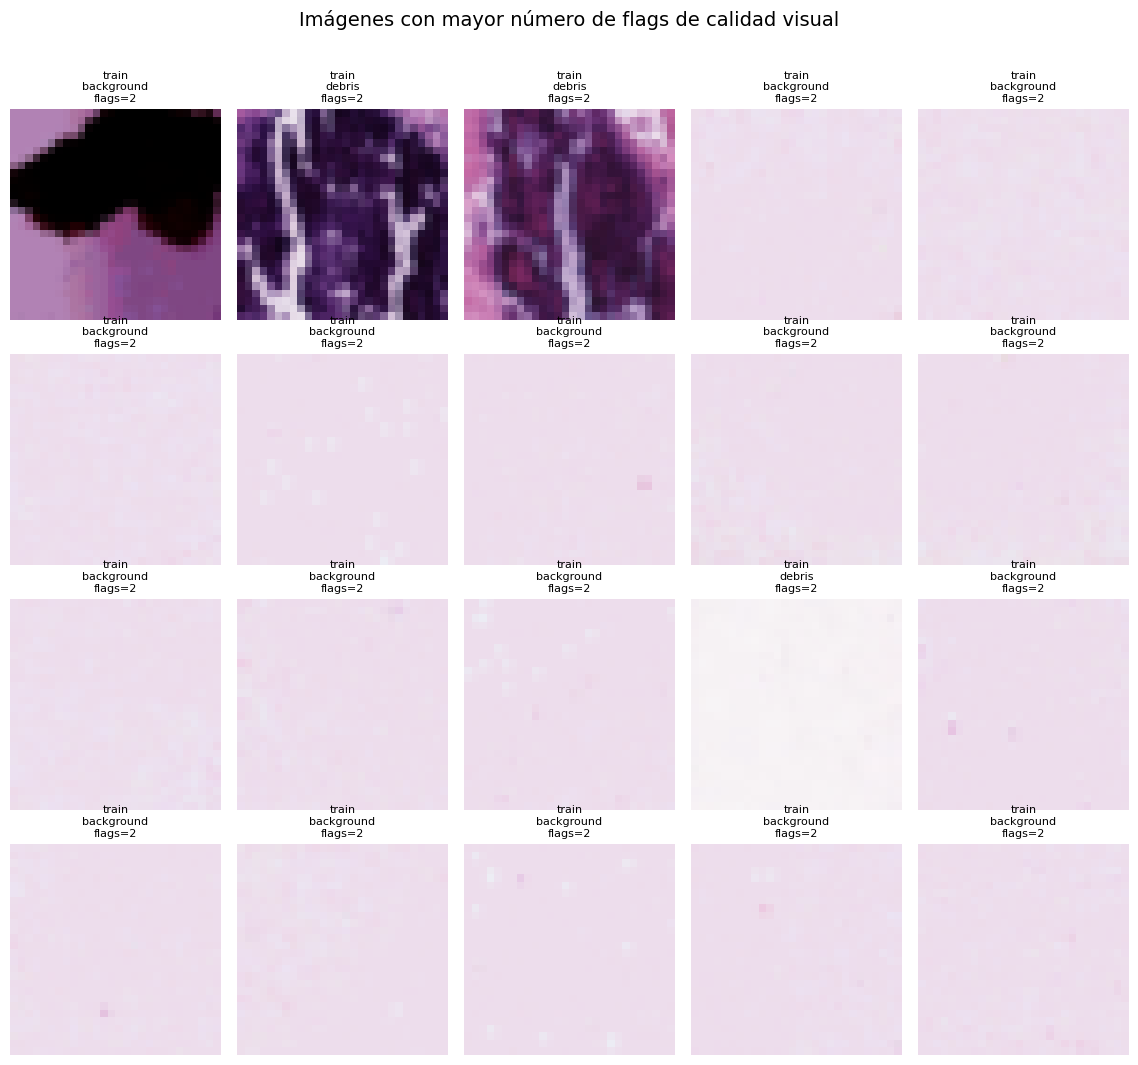

In [49]:
top_flagged_images = image_quality_flags_df[image_quality_flags_df["num_flags"] > 0].sort_values(
    ["num_flags", "std_intensity"], ascending=[False, False]
).head(20)

display(top_flagged_images.round(3))


def plot_selected_quality_cases(selected_df, datasets, title):
    if selected_df.empty:
        print("No hay imágenes seleccionadas para visualizar.")
        return

    n_samples_plot = len(selected_df)
    n_cols = 5
    n_rows = int(np.ceil(n_samples_plot / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.3, n_rows * 2.6))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, selected_df.iterrows()):
        image = datasets[row["split"]].imgs[int(row["image_index"])]
        ax.imshow(image)
        ax.set_title(f"{row['split']}\n{row['class_name']}\nflags={row['num_flags']}", fontsize=8)
        ax.axis("off")

    for ax in axes[n_samples_plot:]:
        ax.axis("off")

    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_selected_quality_cases(
    selected_df=top_flagged_images,
    datasets=datasets,
    title="Imágenes con mayor número de flags de calidad visual",
)


In [50]:
def compute_image_hash(image):
    return hashlib.md5(image.tobytes()).hexdigest()


def build_image_hash_table(datasets):
    rows = []
    for split_name, dataset in datasets.items():
        labels = dataset.labels.reshape(-1).astype(int)
        for idx in range(dataset.imgs.shape[0]):
            class_id = labels[idx]
            rows.append({
                "split": split_name,
                "image_index": idx,
                "class_id": class_id,
                "class_name": class_id_to_name[class_id],
                "image_hash": compute_image_hash(dataset.imgs[idx]),
            })
    return pd.DataFrame(rows)

image_hash_df = build_image_hash_table(datasets)

hash_summary_df = pd.DataFrame({
    "total_images": [len(image_hash_df)],
    "unique_hashes": [image_hash_df["image_hash"].nunique()],
    "duplicated_image_count": [image_hash_df.duplicated("image_hash", keep=False).sum()],
})

within_split_duplicate_rows = []
for split_name in ["train", "validation", "test"]:
    split_df = image_hash_df[image_hash_df["split"] == split_name]
    within_split_duplicate_rows.append({
        "split": split_name,
        "num_images": len(split_df),
        "unique_hashes": split_df["image_hash"].nunique(),
        "duplicated_images": split_df.duplicated("image_hash", keep=False).sum(),
    })
within_split_duplicates_df = pd.DataFrame(within_split_duplicate_rows)

cross_split_duplicate_rows = []
for split_a, split_b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    hashes_a = set(image_hash_df[image_hash_df["split"] == split_a]["image_hash"])
    hashes_b = set(image_hash_df[image_hash_df["split"] == split_b]["image_hash"])
    shared_hashes = hashes_a.intersection(hashes_b)
    cross_split_duplicate_rows.append({
        "comparison": f"{split_a}_vs_{split_b}",
        "shared_exact_hashes": len(shared_hashes),
        "has_exact_leakage": len(shared_hashes) > 0,
    })
cross_split_duplicates_df = pd.DataFrame(cross_split_duplicate_rows)

hash_split_summary = image_hash_df.groupby("image_hash").agg(
    num_occurrences=("image_hash", "count"),
    num_splits=("split", "nunique"),
    splits_present=("split", lambda x: sorted(x.unique().tolist())),
).reset_index()

cross_split_leakage_groups = hash_split_summary[hash_split_summary["num_splits"] > 1]

print("Resumen general de hashes")
display(hash_summary_df)
print("Duplicados dentro de cada split")
display(within_split_duplicates_df)
print("Duplicados exactos entre splits")
display(cross_split_duplicates_df)
print("Grupos presentes en más de un split")
display(cross_split_leakage_groups.head(20))


Resumen general de hashes


,total_images,unique_hashes,duplicated_image_count
0,107180,107180,0


Duplicados dentro de cada split


,split,num_images,unique_hashes,duplicated_images
0,train,89996,89996,0
1,validation,10004,10004,0
2,test,7180,7180,0


Duplicados exactos entre splits


,comparison,shared_exact_hashes,has_exact_leakage
0,train_vs_validation,0,False
1,train_vs_test,0,False
2,validation_vs_test,0,False


Grupos presentes en más de un split


,image_hash,num_occurrences,num_splits,splits_present


---

## Seccion 3 - Preprocesamiento y DataLoaders

- Transformaciones para ResNet18.
- Conversion a tensor.
- Normalizacion.
- Resize a `224x224` para usar ResNet18 preentrenada.
- DataLoaders de `train`, `val` y `test`.
- Verificacion de un batch.


In [51]:



train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

images, labels = next(iter(train_loader))

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print("Forma del batch de imagenes:", images.shape)
print("Forma del batch de etiquetas:", labels.shape)


Train: 89996
Validation: 10004
Test: 7180
Forma del batch de imagenes: torch.Size([256, 3, 224, 224])
Forma del batch de etiquetas: torch.Size([256, 1])


---

## Seccion 4 - Modelo principal: ResNet18 preentrenada

- Cargar ResNet18 con pesos preentrenados.
- Reemplazar capa final para 9 clases.
- Congelar la mayor parte del backbone.
- Entrenar `layer4` y `fc`.
- Mostrar numero de parametros entrenables.


In [52]:
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, n_classes)

for name, param in model.named_parameters():
    param.requires_grad = False

for name, param in model.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

model = model.to(DEVICE)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print("Modelo: ResNet18 pre-entrenada")
print("Parámetros totales:", total_params)
print("Parámetros entrenables:", trainable_params)

Modelo: ResNet18 pre-entrenada
Parámetros totales: 11181129
Parámetros entrenables: 8398345


---

## Seccion 5 - Configuracion de entrenamiento

- Loss: `CrossEntropyLoss`.
- Optimizador: `AdamW`.
- Scheduler: `CosineAnnealingLR`.
- Metricas auxiliares.
- Funciones de entrenamiento y validacion.


In [53]:
from pathlib import Path
def calcular_metricas(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    y_true = []
    y_pred = []

    for images, labels in tqdm(loader, desc="Entrenando", leave=False):
        images = images.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = calcular_metricas(y_true, y_pred)

    return epoch_loss, epoch_metrics

def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluando", leave=False):
            images = images.to(device)
            labels = labels.squeeze().long().to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.detach().cpu().numpy())
            y_pred.extend(preds.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = calcular_metricas(y_true, y_pred)

    return epoch_loss, epoch_metrics, np.array(y_true), np.array(y_pred)


EPOCHS = 50
LEARNING_RATE = 1e-4
EARLY_STOPPING_PATIENCE = 10
MIN_DELTA = 0.001

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=EPOCHS
)

models_dir = Path("outputs/models")
models_dir.mkdir(parents=True, exist_ok=True)

best_model_path = models_dir / "best_model.pth"



metricas_definidas = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro-F1",
        "Weighted-F1"
    ],
    "Uso en el proyecto": [
        "Métrica general de acierto global",
        "Métrica principal para compensar diferencias entre clases",
        "Métrica principal para evaluar desempeño promedio por clase",
        "Métrica complementaria ponderada por cantidad de muestras"
    ]
})

display(metricas_definidas)


,Métrica,Uso en el proyecto
0,Accuracy,Métrica general de acierto global
1,Balanced Accuracy,Métrica principal para compensar diferencias e...
2,Macro-F1,Métrica principal para evaluar desempeño prome...
3,Weighted-F1,Métrica complementaria ponderada por cantidad ...


---

## Seccion 6 - Entrenamiento

- Entrenar usando `train`.
- Validar usando `val`.
- Guardar historial de metricas.
- Guardar mejor modelo segun `val_macro_f1`.


In [54]:
import os
history = []
best_val_macro_f1 = -1.0
early_stopping_counter = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\nÉpoca {epoch}/{EPOCHS}")

    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_metrics, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_macro_f1": val_metrics["macro_f1"], 
        "train_weighted_f1": train_metrics["weighted_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"]
    }

    history.append(row)

    print(pd.DataFrame([row]))

    if val_metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = val_metrics["macro_f1"]
        os.makedirs(os.path.dirname(best_model_path), exist_ok=True)
        torch.save(model.state_dict(), best_model_path)
        print("Nuevo mejor modelo guardado.")
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        print(f"Sin mejora. Patience: {early_stopping_counter}/{EARLY_STOPPING_PATIENCE}")

    scheduler.step() 

    if early_stopping_counter >= EARLY_STOPPING_PATIENCE:
        print("Early stopping activado.")
        break


history_df = pd.DataFrame(history)
display(history_df)

print(f"\n{'='*50}")
print(f"Best epoch: {history_df['val_macro_f1'].idxmax() + 1}")
print(f"Best Macro-F1: {best_val_macro_f1:.4f}")
print(f"Total epochs trained: {len(history_df)}")



Época 1/50


   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0      1    0.358278  0.173369         0.87815      0.943123   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                 0.877753               0.942466        0.878488   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.942956           0.878093          0.94297  
Nuevo mejor modelo guardado.

Época 2/50


   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0      2    0.191014  0.122065         0.93533      0.958317   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                  0.93551               0.956773        0.935815   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.958403           0.935313         0.958009  
Nuevo mejor modelo guardado.

Época 3/50


   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0      3    0.156714  0.104797        0.946253      0.964214   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                 0.946388               0.964045        0.946683   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.964344           0.946231         0.964105  
Nuevo mejor modelo guardado.

Época 4/50


   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0      4     0.14006  0.090117        0.951398      0.971611   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                 0.951695               0.971551        0.951866   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.971805           0.951393         0.971525  
Nuevo mejor modelo guardado.

Época 5/50


...

   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0     32     0.03502  0.044868        0.987777      0.984406   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                 0.987947               0.983706        0.987939   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.984397           0.987781         0.984341  
Sin mejora. Patience: 8/10

Época 33/50


   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0     33    0.034016  0.048399        0.987899      0.983806   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                  0.98807               0.983012        0.988082   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.983716           0.987899         0.983741  
Sin mejora. Patience: 9/10

Época 34/50


   epoch  train_loss  val_loss  train_accuracy  val_accuracy  \
0     34    0.032144  0.045347        0.988922      0.985006   

   train_balanced_accuracy  val_balanced_accuracy  train_macro_f1  \
0                 0.989182               0.984727        0.989147   

   val_macro_f1  train_weighted_f1  val_weighted_f1  
0      0.984966           0.988926         0.984968  
Sin mejora. Patience: 10/10
Early stopping activado.


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_balanced_accuracy,val_balanced_accuracy,train_macro_f1,val_macro_f1,train_weighted_f1,val_weighted_f1
0,1,0.358278,0.173369,0.878150,0.943123,0.877753,0.942466,0.878488,0.942956,0.878093,0.942970
1,2,0.191014,0.122065,0.935330,0.958317,0.935510,0.956773,0.935815,0.958403,0.935313,0.958009
2,3,0.156714,0.104797,0.946253,0.964214,0.946388,0.964045,0.946683,0.964344,0.946231,0.964105
3,4,0.140060,0.090117,0.951398,0.971611,0.951695,0.971551,0.951866,0.971805,0.951393,0.971525
4,5,0.127490,0.082016,0.954942,0.972811,0.955222,0.973111,0.955312,0.972819,0.954943,0.972871
5,6,0.116802,0.089767,0.959387,0.968613,0.959598,0.967440,0.959678,0.968911,0.959394,0.968422
6,7,0.109255,0.076058,0.961865,0.974410,0.962160,0.973872,0.962259,0.974535,0.961867,0.974261
7,8,0.101761,0.069521,0.964587,0.976309,0.964765,0.975963,0.964850,0.976146,0.964591,0.976289
8,9,0.095444,0.068424,0.966699,0.976509,0.967010,0.976027,0.967079,0.976532,0.966707,0.976492
9,10,0.091817,0.066560,0.968110,0.978209,0.968260,0.977966,0.968401,0.978283,0.968112,0.978201



Best epoch: 24
Best Macro-F1: 0.9862
Total epochs trained: 34


---

## Seccion 7 - Evaluacion final en test

- Cargar el mejor modelo.
- Evaluar una sola vez en test.
- Calcular Accuracy, Balanced Accuracy, Macro-F1 y Weighted-F1.
- Generar reporte por clase.


In [55]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_metrics, y_test_true, y_test_pred = evaluate(
    model,
    test_loader,
    criterion,
    DEVICE
)

test_results_df = pd.DataFrame([{
    "test_loss": test_loss,
    "test_accuracy": test_metrics["accuracy"],
    "test_balanced_accuracy": test_metrics["balanced_accuracy"],
    "test_macro_f1": test_metrics["macro_f1"],
    "test_weighted_f1": test_metrics["weighted_f1"]
}])

display(test_results_df)

report = classification_report(
    y_test_true,
    y_test_pred,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)


,test_loss,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1
0,0.278645,0.92507,0.898473,0.896624,0.924602


                                      precision    recall  f1-score   support

                             adipose     0.9574    0.9910    0.9739      1338
                          background     0.9941    1.0000    0.9971       847
                              debris     0.8016    0.8820    0.8399       339
                         lymphocytes     0.9400    0.9890    0.9639       634
                               mucus     0.9906    0.9169    0.9523      1035
                       smooth muscle     0.8032    0.7652    0.7837       592
                 normal colon mucosa     0.9458    0.9177    0.9315       741
            cancer-associated stroma     0.6904    0.6675    0.6787       421
colorectal adenocarcinoma epithelium     0.9402    0.9570    0.9486      1233

                            accuracy                         0.9251      7180
                           macro avg     0.8959    0.8985    0.8966      7180
                        weighted avg     0.9251    0.9251    0

---

## Seccion 8 - Visualizaciones finales

- Curvas de loss.
- Curvas de metricas en validacion.
- Matriz de confusion.
- Tabla resumen de metricas.


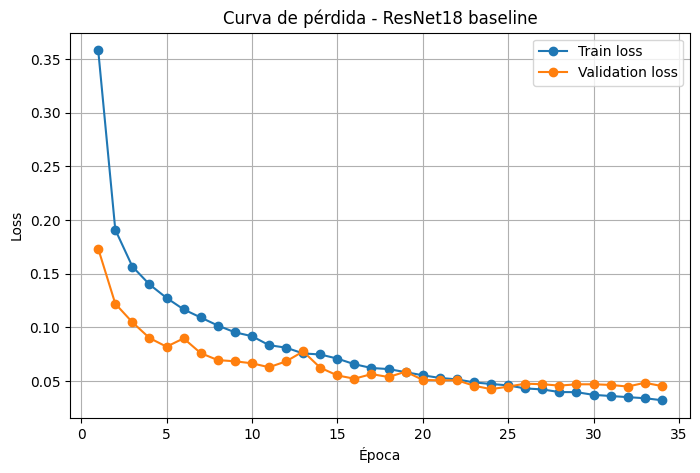

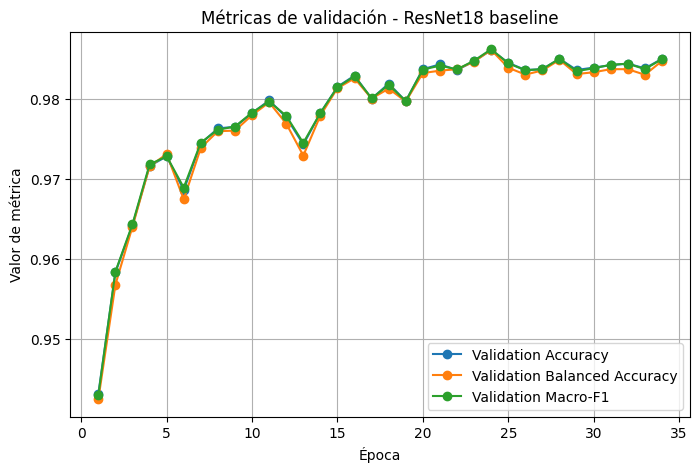

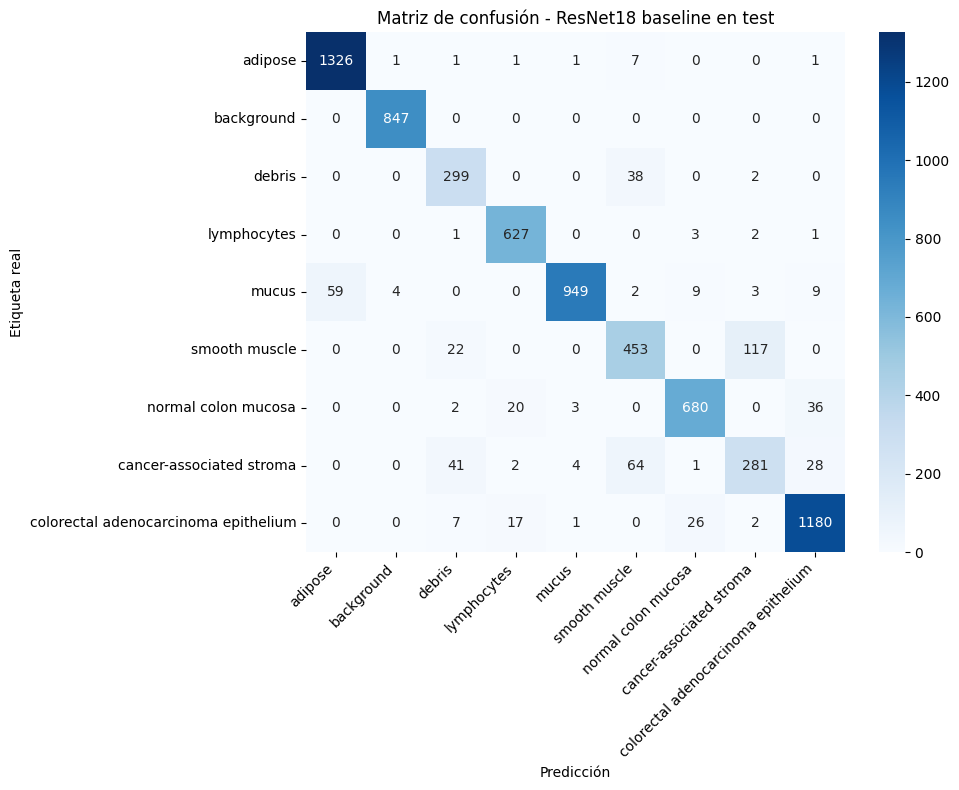

In [56]:


plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de pérdida - ResNet18 baseline")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Validation Accuracy")
plt.plot(history_df["epoch"], history_df["val_balanced_accuracy"], marker="o", label="Validation Balanced Accuracy")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="Validation Macro-F1")
plt.xlabel("Época")
plt.ylabel("Valor de métrica")
plt.title("Métricas de validación - ResNet18 baseline")
plt.legend()
plt.grid(True)
plt.show()

cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión - ResNet18 baseline en test")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



---

## Seccion 9 - Conclusiones breves

- Resultado principal.
- Limitaciones de trabajar en 28x28.
- Observacion sobre resolucion baja.
- Trabajo futuro: 128x128 y Transformers para la segunda entrega.


In [57]:
best_epoch = history_df.loc[history_df["val_macro_f1"].idxmax()]

summary_df = pd.DataFrame({
    "Elemento": [
        "Dataset",
        "Resolución",
        "Diseño experimental",
        "Modelo CNN baseline",
        "Fine-tuning",
        "Métrica principal 1",
        "Métrica principal 2",
        "Mejor época según validation",
        "Test Accuracy",
        "Test Balanced Accuracy",
        "Test Macro-F1",
        "Test Weighted-F1"
    ],
    "Resultado": [
        "PathMNIST",
        "28x28 RGB",
        "Hold-out oficial: train / validation / test",
        "ResNet18 pre-entrenada",
        "Parcial: layer4 + fc entrenables",
        "Macro-F1",
        "Balanced Accuracy",
        int(best_epoch["epoch"]),
        round(test_metrics["accuracy"], 4),
        round(test_metrics["balanced_accuracy"], 4),
        round(test_metrics["macro_f1"], 4),
        round(test_metrics["weighted_f1"], 4)
    ]
})

display(summary_df)

,Elemento,Resultado
0,Dataset,PathMNIST
1,Resolución,28x28 RGB
2,Diseño experimental,Hold-out oficial: train / validation / test
3,Modelo CNN baseline,ResNet18 pre-entrenada
4,Fine-tuning,Parcial: layer4 + fc entrenables
5,Métrica principal 1,Macro-F1
6,Métrica principal 2,Balanced Accuracy
7,Mejor época según validation,24
8,Test Accuracy,0.9251
9,Test Balanced Accuracy,0.8985


---
